In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load raw dataset
df = pd.read_csv('../data/raw/ai4i2020.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [2]:
# Check data types and missing values
print("--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Summary Statistics ---")
display(df.describe().T)

--- Missing Values ---
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

--- Summary Statistics ---


,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.30,300.1,301.50,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.80,310.1,311.10,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.00,1503.0,1612.00,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.20,40.1,46.80,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.00,108.0,162.00,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.00,0.0,0.00,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.00,0.0,0.00,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.00,0.0,0.00,1.0


Non-Failures (0): 9661 (96.61%)
Failures (1):     339 (3.39%)


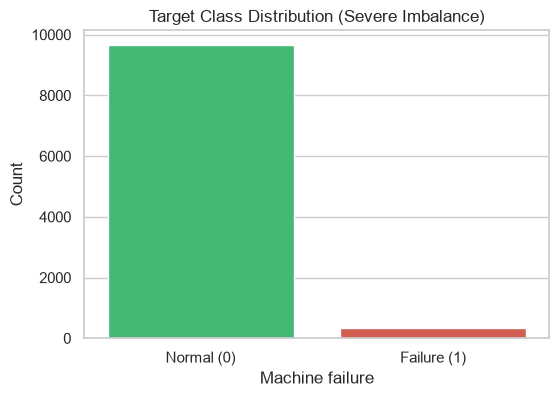

In [5]:
# Binary target: 'Machine failure' (or 'Target' depending on original CSV naming)
target_col = 'Machine failure' if 'Machine failure' in df.columns else 'Target'

failure_counts = df[target_col].value_counts()
failure_percentages = df[target_col].value_counts(normalize=True) * 100

print(f"Non-Failures (0): {failure_counts[0]} ({failure_percentages[0]:.2f}%)")
print(f"Failures (1):     {failure_counts[1]} ({failure_percentages[1]:.2f}%)")

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(
    x=target_col, 
    data=df, 
    hue=target_col, 
    palette=['#2ecc71', '#e74c3c'], 
    legend=False, 
    ax=ax
)
plt.title('Target Class Distribution (Severe Imbalance)')
plt.xticks([0, 1], ['Normal (0)', 'Failure (1)'])
plt.ylabel('Count')
plt.savefig('../models/eda_target_distribution.png', bbox_inches='tight')
plt.show()

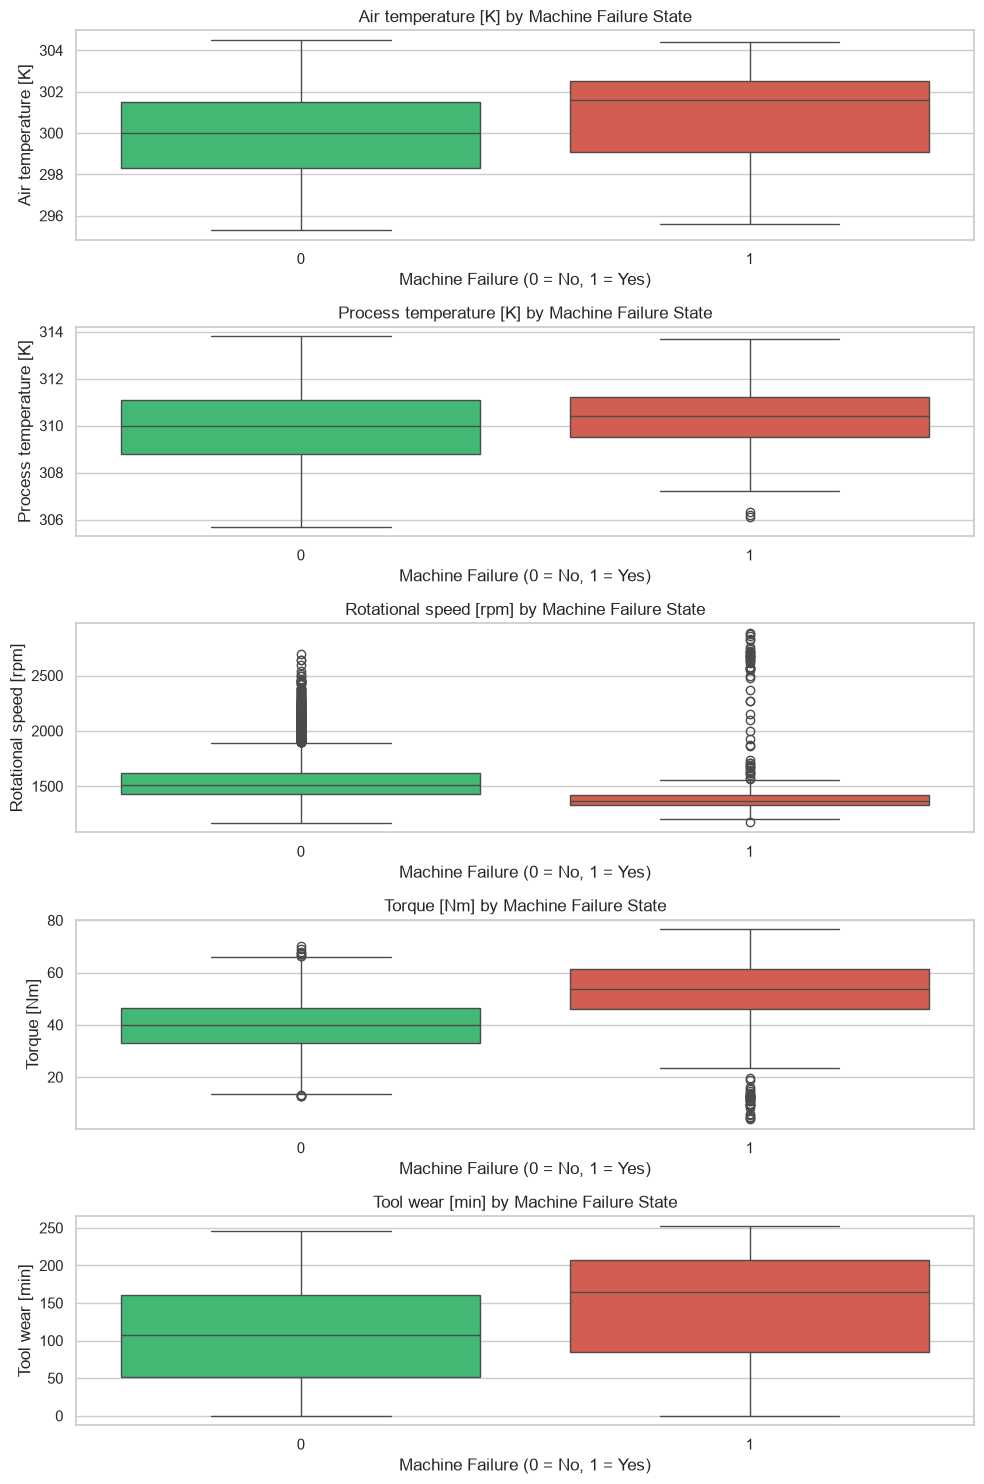

In [6]:
sensor_cols = [
    'Air temperature [K]', 
    'Process temperature [K]', 
    'Rotational speed [rpm]', 
    'Torque [Nm]', 
    'Tool wear [min]'
]

# Filter down to columns that exist in the raw dataset
sensor_cols = [col for col in sensor_cols if col in df.columns]

fig, axes = plt.subplots(len(sensor_cols), 1, figsize=(10, 3 * len(sensor_cols)))

for idx, col in enumerate(sensor_cols):
    sns.boxplot(
    x=target_col, 
    y=col, 
    data=df, 
    hue=target_col, 
    palette=['#2ecc71', '#e74c3c'], 
    legend=False, 
    ax=axes[idx]
)
    axes[idx].set_title(f'{col} by Machine Failure State')
    axes[idx].set_xlabel('Machine Failure (0 = No, 1 = Yes)')

plt.tight_layout()
plt.savefig('../models/eda_sensor_boxplots.png', bbox_inches='tight')
plt.show()